# UnconBacktest Example: TS Momentum in Cryptocurrencies

We will run a simple "uncon backtest" to test whether 4 of the larger coins (BTC, ETH, ADA, BNB) show time-series momentum. In other words, if they have done well recently, do they tend to continue to do well?

1. Run the first cell to compute returns for these coins since 2016.
2. The signal on each day for each coin will be: sqrt(10)*(avg past 10 day ret - avg past 365 day ret) / (stdev past 365 day ret). You can think of this as the z-score of the past 10 day returns, and it tells us if a coin is doing better than it usually does. Technical note: we multiply by sqrt(10) here because the stdev is calculated on daily data but we want to "z-score" the average 10 day returns.
3. The signal from (2) will have extreme values. Pass them through a tanh function to curtail these. These are your final daily portfolio weights.
4. Compute the returns to the weights from (3). 
5. What is the Sharpe of these strategies? Plot their cumulative returns.
6. How correlated are the timing strategies with the underlying assets?

In [1]:
# compute returns 
import yfinance as yf 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

data = yf.download(['ADA-USD','BNB-USD','BTC-USD','ETH-USD'],'2016-1-1')
ret = data['Close'] / data['Close'].shift() - 1

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  4 of 4 completed


Text(0, 0.5, 'Signal Value')

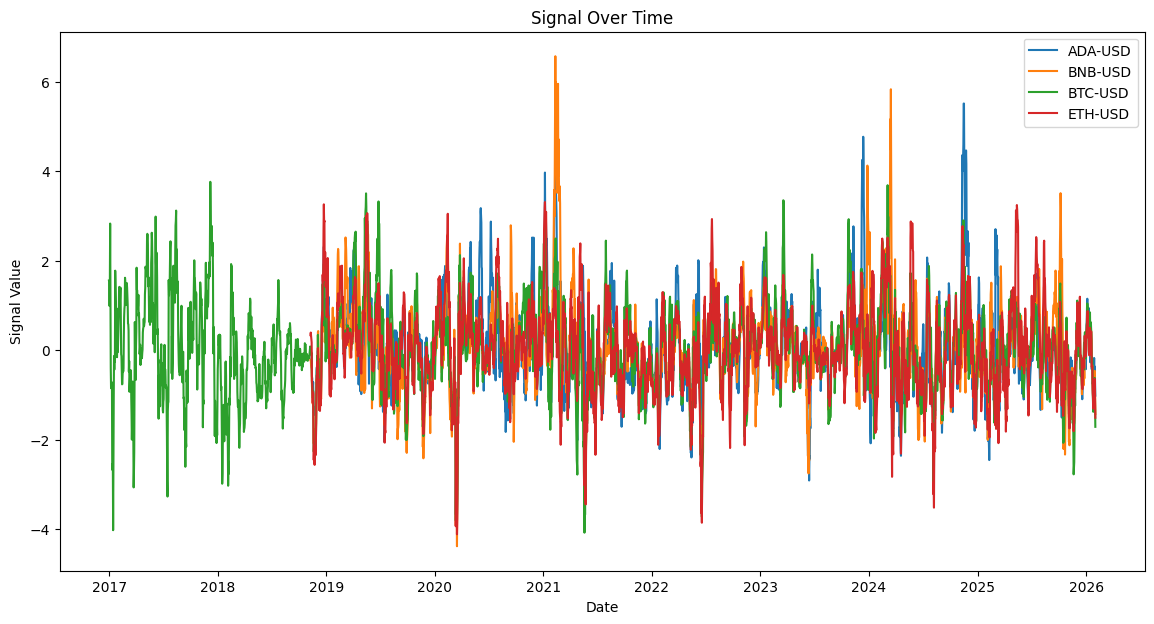

In [2]:
# Compute rolling averages and std
avg_10 = ret.rolling(window=10).mean()
avg_365 = ret.rolling(window=365).mean()
std_365 = ret.rolling(window=365).std()

# Calculate the signal
signal = np.sqrt(10) * (avg_10 - avg_365) / std_365

# Plot the signal
plt.figure(figsize=(14, 7))
for coin in signal.columns:
    plt.plot(signal.index, signal[coin], label=coin)
plt.legend()
plt.title("Signal Over Time")
plt.xlabel("Date")
plt.ylabel("Signal Value")

In [3]:
# Calculate the weights
weights = np.tanh(signal)
weights

Ticker,ADA-USD,BNB-USD,BTC-USD,ETH-USD
Date,,,,
2016-01-01,NaN,NaN,NaN,NaN
2016-01-02,NaN,NaN,NaN,NaN
2016-01-03,NaN,NaN,NaN,NaN
2016-01-04,NaN,NaN,NaN,NaN
2016-01-05,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-01-27,-0.402325,-0.625571,-0.719308,-0.624222
2026-01-28,-0.174925,-0.477350,-0.584917,-0.612280
2026-01-29,-0.417506,-0.674360,-0.840737,-0.747134


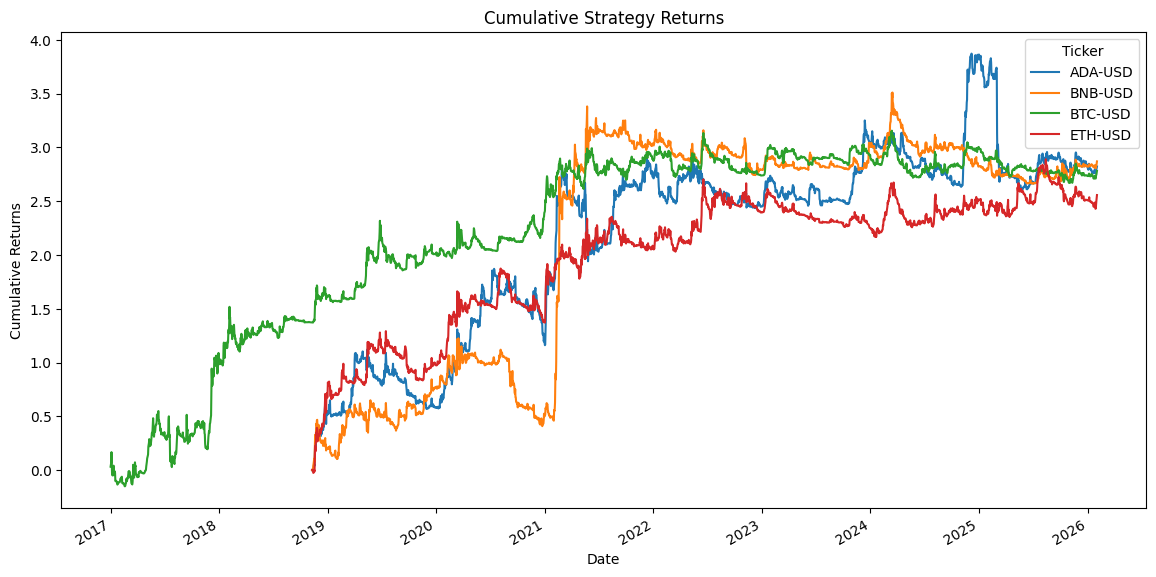

In [4]:
# Calculate strategy returns
strat_returns = weights.shift() * ret

# Plot cumulative returns
strat_returns.cumsum().plot(figsize=(14, 7))
plt.title("Cumulative Strategy Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.show()


In [5]:
# Calculate Sharpe Ratio
sharpe_ratio = strat_returns.mean() / strat_returns.std() * np.sqrt(365)
sharpe_ratio

Ticker
ADA-USD    0.569751
BNB-USD    0.633190
BTC-USD    0.633378
ETH-USD    0.642584
dtype: float64

In [6]:
# Find correlation between signals
correlation = strat_returns.corrwith(ret)
correlation

Ticker
ADA-USD   -0.018680
BNB-USD    0.124893
BTC-USD   -0.142657
ETH-USD   -0.112018
dtype: float64